# 03 — Microstructure Features

Visualize each feature from Phase 5 over a week of synthetic BTCUSDT data.
Flag any NaNs or outliers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)

# Generate 1 week of 1-minute synthetic BTCUSDT data
n = 7 * 24 * 60  # 10080 bars
rng = np.random.default_rng(42)

close = 30000.0 + np.cumsum(rng.normal(0, 10, n))
close = np.maximum(close, 20000.0)
high = close + rng.uniform(5, 50, n)
low = close - rng.uniform(5, 50, n)
open_ = close + rng.normal(0, 15, n)
volume = rng.uniform(10, 500, n)

bid_price = close - rng.uniform(0.5, 5, n)
ask_price = close + rng.uniform(0.5, 5, n)
bid_size = rng.uniform(0.1, 10, n)
ask_size = rng.uniform(0.1, 10, n)

funding = np.where(rng.random(n) > 0.875, rng.normal(0.0001, 0.0005, n), np.nan)
spot_price = close - rng.uniform(0, 10, n)
btc_return = np.log(close / np.roll(close, 1))
btc_return[0] = 0

df = pd.DataFrame(
    {
        "event_time": pd.date_range("2023-06-01", periods=n, freq="1min"),
        "open": open_,
        "high": high,
        "low": low,
        "close": close,
        "volume": volume,
        "bid_price": bid_price,
        "ask_price": ask_price,
        "bid_size": bid_size,
        "ask_size": ask_size,
        "funding_rate": funding,
        "spot_price": spot_price,
        "btc_return": btc_return,
    }
)
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (10080, 13)


,event_time,open,high,low,close,volume,bid_price,ask_price,bid_size,ask_size,funding_rate,spot_price,btc_return
0,2023-06-01 00:00:00,29997.877855,30051.889275,29992.547720,30003.047171,370.055100,29998.938336,30006.142063,9.964939,3.447802,-0.000398,29993.257986,0.000000
1,2023-06-01 00:01:00,30000.129548,30016.429815,29963.484556,29992.647330,352.213687,29989.657467,29996.890473,6.583377,4.351959,NaN,29990.347372,-0.000347
2,2023-06-01 00:02:00,29998.106624,30041.479911,29984.065200,30000.151842,395.009611,29998.746144,30004.099343,0.347650,8.354314,0.000444,29992.260348,0.000250
3,2023-06-01 00:03:00,30007.461356,30038.226999,29977.269892,30009.557489,350.152819,30005.233141,30012.025370,0.651138,9.444542,NaN,30009.475137,0.000313
4,2023-06-01 00:04:00,29987.398483,30005.125420,29983.380940,29990.047137,40.114143,29987.411817,29991.908012,5.838865,3.324468,-0.000223,29989.374774,-0.000650


In [2]:
from tessera.features import (
    VPIN,
    BetaToBTC,
    FeaturePipeline,
    FundingRate,
    FundingZScore,
    GarmanKlass,
    IdiosyncraticResidual,
    LogReturn,
    MicroPrice,
    OrderFlowImbalance,
    Parkinson,
    RealizedVol,
    SpotPerpBasis,
    SpreadBps,
    UniverseRank,
    VolOfVol,
)

features = [
    LogReturn(horizon=1),
    LogReturn(horizon=5),
    LogReturn(horizon=60),
    RealizedVol(window=300),
    RealizedVol(window=60),
    Parkinson(window=60),
    GarmanKlass(window=60),
    VolOfVol(window=60),
    OrderFlowImbalance(depth=1),
    MicroPrice(),
    SpreadBps(),
    VPIN(bucket_size=1000, window=50),
    FundingRate(),
    FundingZScore(window=720),
    SpotPerpBasis(),
    BetaToBTC(window=1440),
    IdiosyncraticResidual(window=1440),
    UniverseRank(metric="log_return_1"),
]

pipeline = FeaturePipeline(features, cache_dir=None)
result = pipeline.compute(df, symbol="BTCUSDT", use_cache=False)
print(f"Result shape: {result.shape}")
print(f"Feature columns: {[f.name for f in features]}")

2026-05-17 15:06:33 [debug    ] computing_feature              feature=log_return_1 symbol=BTCUSDT


2026-05-17 15:06:33 [debug    ] computing_feature              feature=log_return_5 symbol=BTCUSDT


2026-05-17 15:06:33 [debug    ] computing_feature              feature=log_return_60 symbol=BTCUSDT


2026-05-17 15:06:33 [debug    ] computing_feature              feature=realized_vol_300 symbol=BTCUSDT


2026-05-17 15:06:33 [debug    ] computing_feature              feature=realized_vol_60 symbol=BTCUSDT


...

2026-05-17 15:06:33 [debug    ] computing_feature              feature=rank_log_return_1 symbol=BTCUSDT


2026-05-17 15:06:33 [debug    ] computing_feature              feature=vol_of_vol_60 symbol=BTCUSDT


2026-05-17 15:06:33 [debug    ] computing_feature              feature=funding_zscore_720 symbol=BTCUSDT


2026-05-17 15:06:33 [debug    ] computing_feature              feature=idio_residual_1440 symbol=BTCUSDT


Result shape: (10080, 30)
Feature columns: ['log_return_1', 'log_return_5', 'log_return_60', 'realized_vol_300', 'realized_vol_60', 'parkinson_vol_60', 'garman_klass_vol_60', 'vol_of_vol_60', 'ofi_1', 'microprice', 'spread_bps', 'vpin_1000_50', 'funding_rate', 'funding_zscore_720', 'spot_perp_basis', 'beta_btc_1440', 'idio_residual_1440', 'rank_log_return_1']


In [3]:
# NaN report
feature_names = [f.name for f in features]
nan_report = result[feature_names].isna().sum()
nan_pct = nan_report / len(result) * 100
print("=== NaN Report ===")
for name in feature_names:
    pct = nan_pct[name]
    flag = " ⚠️ HIGH" if pct > 50 else ""
    print(f"  {name:30s}: {nan_report[name]:5d} NaNs ({pct:.1f}%){flag}")

=== NaN Report ===
  log_return_1                  :     1 NaNs (0.0%)
  log_return_5                  :     5 NaNs (0.0%)
  log_return_60                 :    60 NaNs (0.6%)
  realized_vol_300              :   300 NaNs (3.0%)
  realized_vol_60               :    60 NaNs (0.6%)
  parkinson_vol_60              :    59 NaNs (0.6%)
  garman_klass_vol_60           :    59 NaNs (0.6%)
  vol_of_vol_60                 :   120 NaNs (1.2%)
  ofi_1                         :     1 NaNs (0.0%)
  microprice                    :     0 NaNs (0.0%)
  spread_bps                    :     0 NaNs (0.0%)
  vpin_1000_50                  :   183 NaNs (1.8%)
  funding_rate                  :     0 NaNs (0.0%)
  funding_zscore_720            :     0 NaNs (0.0%)
  spot_perp_basis               :     0 NaNs (0.0%)
  beta_btc_1440                 :  1440 NaNs (14.3%)
  idio_residual_1440            :  1440 NaNs (14.3%)
  rank_log_return_1             :     1 NaNs (0.0%)


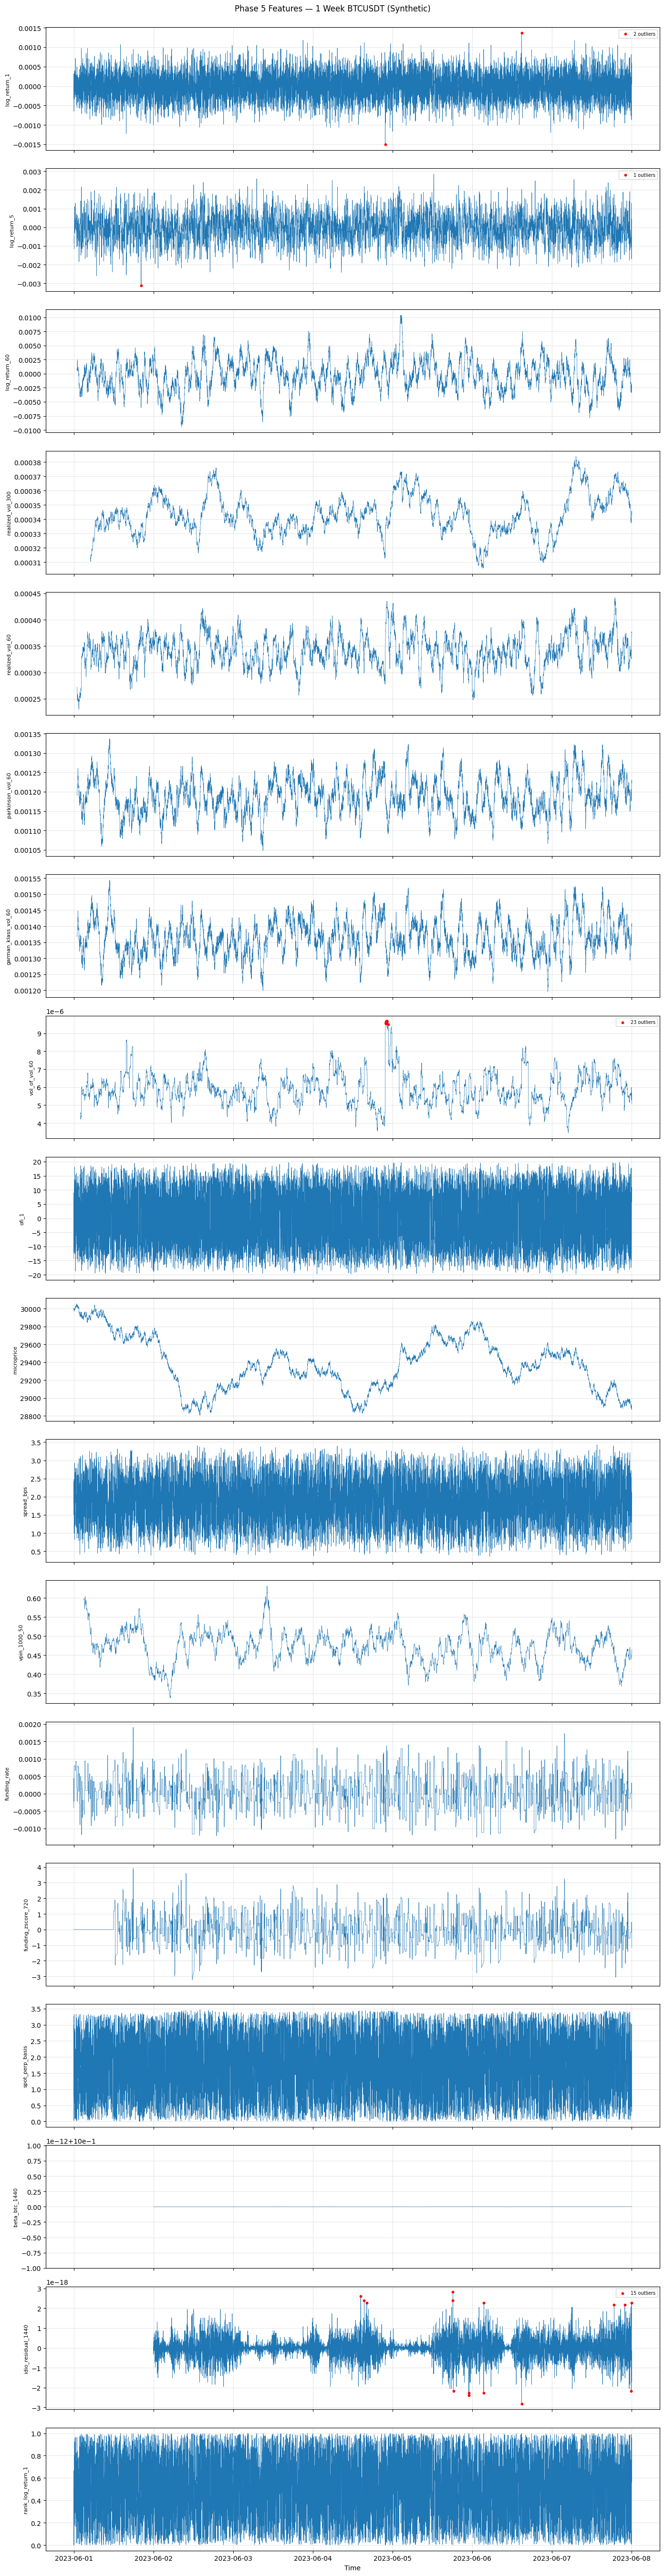

In [4]:
# Visualize each feature
fig, axes = plt.subplots(len(feature_names), 1, figsize=(14, 3 * len(feature_names)), sharex=True)

for ax, name in zip(axes, feature_names, strict=False):
    series = result[name].dropna()
    ax.plot(result["event_time"].iloc[series.index], series.values, linewidth=0.5)
    ax.set_ylabel(name, fontsize=8)
    ax.grid(True, alpha=0.3)

    # Flag outliers (>4 std)
    if len(series) > 0:
        mean, std = series.mean(), series.std()
        if std > 0:
            outliers = series[abs(series - mean) > 4 * std]
            if len(outliers) > 0:
                ax.scatter(
                    result["event_time"].iloc[outliers.index],
                    outliers.values,
                    c="red",
                    s=10,
                    zorder=5,
                    label=f"{len(outliers)} outliers",
                )
                ax.legend(fontsize=7)

axes[-1].set_xlabel("Time")
plt.suptitle("Phase 5 Features — 1 Week BTCUSDT (Synthetic)", y=1.0)
plt.tight_layout()
plt.savefig("../docs/figures/features_visualization.png", dpi=100, bbox_inches="tight")
plt.show()

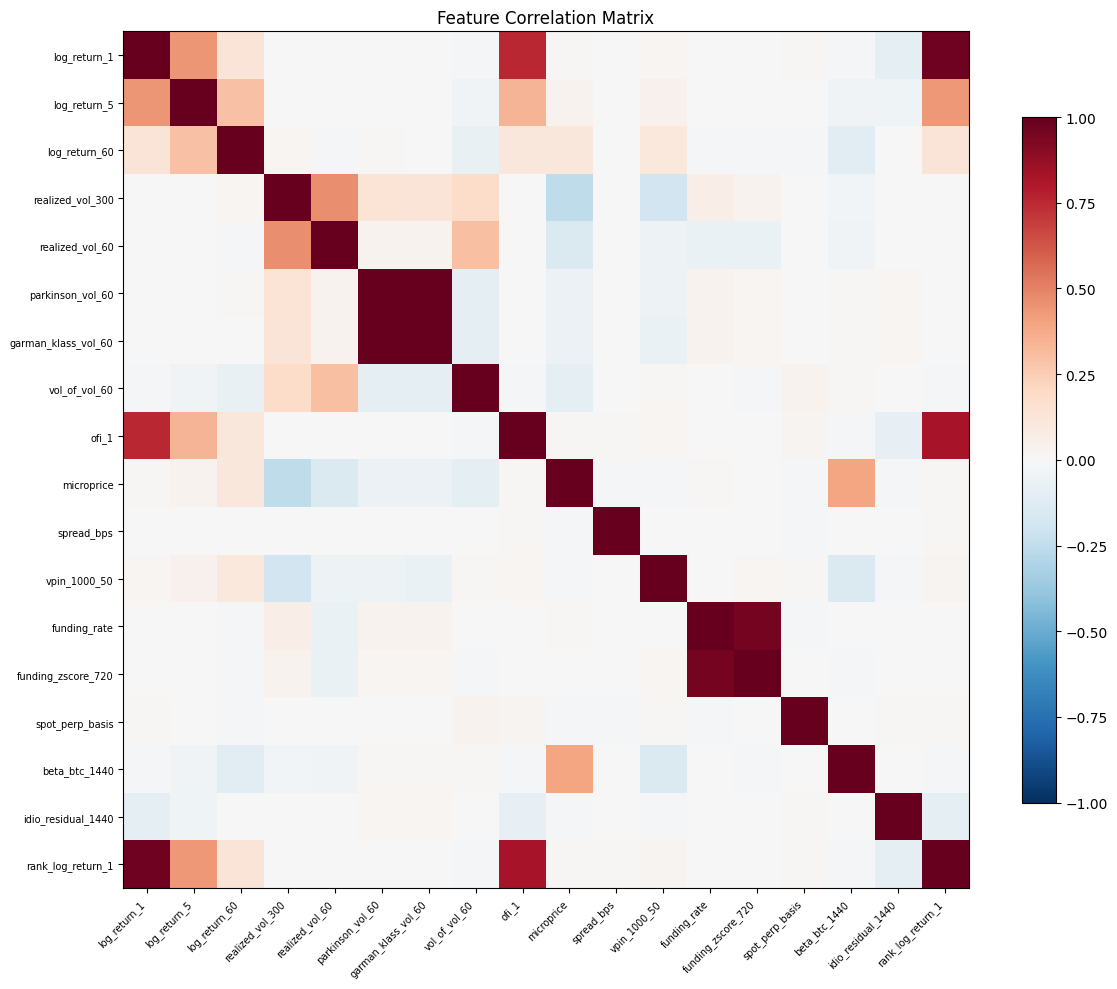


=== High correlations (|r| > 0.8) ===
  log_return_1 ↔ rank_log_return_1: 0.974
  parkinson_vol_60 ↔ garman_klass_vol_60: 0.993
  ofi_1 ↔ rank_log_return_1: 0.821
  funding_rate ↔ funding_zscore_720: 0.954


In [5]:
# Correlation matrix of all features
corr = result[feature_names].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(feature_names, fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../docs/figures/feature_correlation_matrix.png", dpi=100, bbox_inches="tight")
plt.show()

print("\n=== High correlations (|r| > 0.8) ===")
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            print(f"  {feature_names[i]} ↔ {feature_names[j]}: {r:.3f}")

In [6]:
# Summary statistics
print("=== Feature Summary Statistics ===")
result[feature_names].describe().T

=== Feature Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
log_return_1,10079.0,-3.683970e-06,3.427312e-04,-1.504002e-03,-2.316916e-04,-4.380786e-06,2.213425e-04,1.370967e-03
log_return_5,10075.0,-1.858509e-05,7.667944e-04,-3.130282e-03,-5.347933e-04,-1.475521e-05,4.915087e-04,2.852655e-03
log_return_60,10020.0,-2.171831e-04,2.776769e-03,-9.452519e-03,-2.048915e-03,-2.113283e-04,1.619983e-03,1.036839e-02
realized_vol_300,9780.0,3.428386e-04,1.391931e-05,3.057241e-04,3.336423e-04,3.418159e-04,3.513429e-04,3.839817e-04
realized_vol_60,10020.0,3.410720e-04,3.065124e-05,2.299425e-04,3.209659e-04,3.415109e-04,3.609159e-04,4.421795e-04
parkinson_vol_60,10021.0,1.189235e-03,4.605644e-05,1.048161e-03,1.158445e-03,1.187127e-03,1.221341e-03,1.336814e-03
garman_klass_vol_60,10021.0,1.363096e-03,5.600722e-05,1.195338e-03,1.324919e-03,1.361130e-03,1.402315e-03,1.544396e-03
vol_of_vol_60,9960.0,5.892754e-06,8.866744e-07,3.451973e-06,5.310459e-06,5.819370e-06,6.413326e-06,9.672662e-06
ofi_1,10079.0,-6.488964e-02,1.050249e+01,-1.980413e+01,-9.723607e+00,-5.483348e-01,9.674273e+00,1.972505e+01
microprice,10080.0,2.937933e+04,2.913425e+02,2.880637e+04,2.915269e+04,2.936793e+04,2.960146e+04,3.005472e+04
